# Project 1 — Issue Report Classification
## Notebook 02: Evaluation protocol, metrics and reference floors

**Track D deliverable.** Artificial Intelligence for Software Engineering, 2026–2027.

This notebook defines how every model in the project is measured, and establishes the floors any real model must clear. It covers:

1. **Metrics** — precision, recall, F1, confusion matrix, and the difference between macro and micro averaging.
2. **Cross-validation** — stratified k-fold on the *training* split, for model selection.
3. **The competition protocol** — one classifier per project, evaluated on the *test* split, for the final comparison with the published baseline.
4. **Reference floors** — what trivial and near-trivial approaches score, so later results can be read in context.

Tracks B and C plug their models into the runners here. Nothing in this notebook trains a competitive model; that is their job.

In [1]:
from pathlib import Path

from ai4se.baselines import (
    REFERENCE_MODELS,
    KeywordClassifier,
    MajorityClassifier,
    MultinomialNaiveBayes,
    StratifiedRandomClassifier,
)
from ai4se.evaluation import (
    RANDOM_SEED,
    SETFIT_BASELINE,
    SETFIT_OVERALL,
    cross_validate,
    cross_validate_per_project,
    evaluate_competition,
    leaderboard,
    save_result,
    stratified_folds,
    to_latex,
)
from ai4se.loader import PROJECT_ROOT, load_split
from ai4se.metrics import evaluate
from ai4se.model import LABELS, REPOSITORIES
from ai4se.preprocessing import make_cleaner

%matplotlib inline
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option("display.width", 140)

RESULTS = PROJECT_ROOT / "results"
print("seed:", RANDOM_SEED)
print("baseline to beat:", SETFIT_OVERALL)

seed: 42
baseline to beat: 0.827


---
## 1. Load the cleaned data

Track A wrote the cleaned splits to `data/processed/`. Loading them here rather than re-running the cleaning guarantees every track measures models on identical inputs.

In [2]:
train = load_split("train", kind="memory")
test  = load_split("test",  kind="memory")

cleaner = make_cleaner(level="full", max_words=400)
train.apply(cleaner)
test.apply(cleaner)

print(train, "|", test)
print("train distribution:", train.label_distribution())
print("test  distribution:", test.label_distribution())

InMemoryIssueRepository(n=1500) | InMemoryIssueRepository(n=1500)
train distribution: {'bug': 500, 'feature': 500, 'question': 500}
test  distribution: {'bug': 500, 'feature': 500, 'question': 500}


---
## 2. Metrics

Everything is derived from the confusion matrix. For a class `c`:

$$\text{precision} = \frac{TP}{TP + FP} \qquad \text{recall} = \frac{TP}{TP + FN} \qquad F_1 = \frac{2PR}{P + R}$$

The metrics are implemented from scratch in `ai4se.metrics` rather than imported from scikit-learn, and `tests/test_evaluation.py` verifies them against scikit-learn to twelve decimal places. Two reasons: the evaluation module then has no dependency on a modelling library, and deriving these from a confusion matrix is exactly what the oral exam asks about.

### 2.1 A worked example

In [3]:
y_true = ["bug", "bug", "feature", "question"]
y_pred = ["bug", "feature", "feature", "bug"]

scores = evaluate(y_true, y_pred, labels=LABELS)
print("confusion matrix (rows: true, columns: predicted)")
display(scores.confusion_frame())
display(scores.to_frame())

confusion matrix (rows: true, columns: predicted)


predicted,bug,feature,question
true,,,
bug,1,1,0
feature,0,1,0
question,1,0,0


,precision,recall,f1,support
class,,,,
bug,0.5000,0.5,0.5000,2
feature,0.5000,1.0,0.6667,1
question,0.0000,0.0,0.0000,1
macro avg,0.3333,0.5,0.3889,4


Reading the `bug` row by hand: one bug was classified correctly (TP = 1), one bug was called a feature (FN = 1), and one question was called a bug (FP = 1). So precision = 1/2, recall = 1/2, F1 = 1/2.

The `question` class scores zero on everything — it was never predicted. This is the situation macro averaging is designed to expose and accuracy is designed to hide.

### 2.2 Why report macro, micro and weighted

The three averages answer different questions, and the gap between them is informative in itself.

In [4]:
# A model that ignores two of the three classes entirely.
y_true = list(LABELS) * 100
y_pred = ["bug"] * 300

lazy = evaluate(y_true, y_pred, labels=LABELS)
pd.DataFrame([{
    "accuracy": lazy.accuracy,
    "micro F1": lazy.micro_f1,
    "macro F1": lazy.macro_f1,
    "weighted F1": lazy.weighted_f1,
}], index=["always predicts 'bug'"]).round(4)

,accuracy,micro F1,macro F1,weighted F1
always predicts 'bug',0.3333,0.3333,0.1667,0.1667


Accuracy and micro F1 report 0.33 — they reward the third of the data it happens to get right. Macro F1 reports 0.167, because two classes score zero and every class counts equally.

**On this dataset specifically:** the splits are exactly balanced at 100 issues per (project, class) cell, so for a model that predicts all three classes at similar rates, macro and micro converge. Report both anyway. If any resampling or filtering is introduced during development, the two will diverge immediately and that divergence is the signal that something changed.

`micro F1 == accuracy` is a property of single-label multi-class problems, not a coincidence; there is a test asserting it.

---
## 3. Stratified k-fold cross-validation

From the course: the dataset is split into k equal parts, k−1 are used for training and 1 for testing, repeated k times. **Stratified** means each fold preserves the class proportions of the whole.

The splitter is in `ai4se.evaluation.stratified_folds` and is seeded, so every group member gets identical folds and identical numbers.

⚠️ **Cross-validation runs on the training split only.** The test split is the competition's held-out set and is touched exactly once, at the very end. Using it for model selection would make every comparison with the published baseline meaningless.

In [5]:
labels = [issue.label for issue in train]
folds = list(stratified_folds(labels, k=10, seed=RANDOM_SEED))

rows = []
for i, (train_idx, val_idx) in enumerate(folds, start=1):
    held_out = [labels[j] for j in val_idx]
    rows.append({
        "fold": i,
        "train": len(train_idx),
        "validate": len(val_idx),
        **{label: held_out.count(label) for label in LABELS},
    })
pd.DataFrame(rows).set_index("fold")

,train,validate,bug,feature,question
fold,,,,,
1,1350,150,50,50,50
2,1350,150,50,50,50
3,1350,150,50,50,50
4,1350,150,50,50,50
5,1350,150,50,50,50
6,1350,150,50,50,50
7,1350,150,50,50,50
8,1350,150,50,50,50
9,1350,150,50,50,50


Every fold holds 150 issues, 50 per class — the proportions of the full training set, exactly preserved.

---
## 4. Reference floors

A result means nothing without knowing what costs no effort. Four references, in increasing order of sophistication:

| Model | What it does |
|---|---|
| `MajorityClassifier` | Always predicts the most frequent training class |
| `StratifiedRandomClassifier` | Predicts randomly, in proportion to training frequencies |
| `KeywordClassifier` | Hand-written cue-word rules, from the Track A term analysis |
| `MultinomialNaiveBayes` | Naive Bayes over word counts, implemented from scratch |

All four satisfy the same `fit`/`predict` interface as a scikit-learn pipeline or a wrapped transformer, so they run through exactly the same code paths as tracks B and C will.

In [6]:
cv_results = {}
for name, factory in REFERENCE_MODELS.items():
    cv_results[name] = cross_validate(factory, train, k=10, model_name=name)
    r = cv_results[name]
    print(f"{name:<30} macro F1 = {r.mean_macro_f1:.4f} ± {r.std_macro_f1:.4f}")

majority                       macro F1 = 0.1667 ± 0.0000
random (stratified)            macro F1 = 0.3626 ± 0.0145
keyword rules                  macro F1 = 0.5107 ± 0.0340


naive Bayes (from scratch)     macro F1 = 0.6009 ± 0.0461


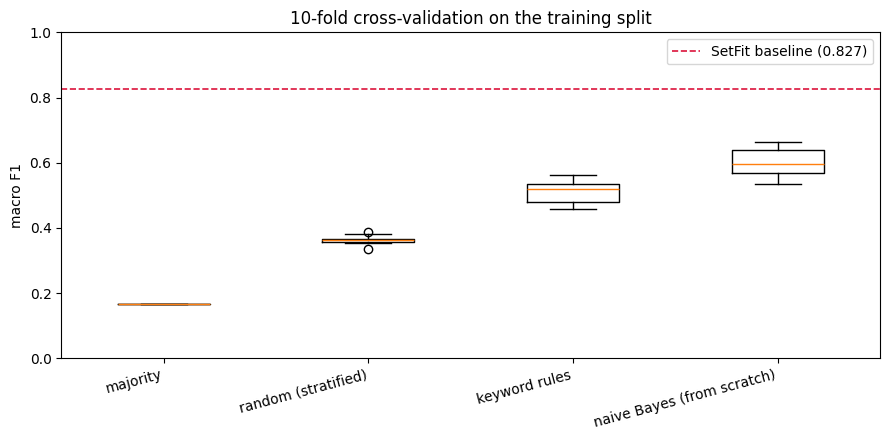

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
names = list(cv_results)
ax.boxplot([cv_results[n].macro_f1_per_fold for n in names], tick_labels=names)
ax.axhline(SETFIT_OVERALL, color="crimson", linestyle="--", linewidth=1.2,
           label=f"SetFit baseline ({SETFIT_OVERALL})")
ax.set_ylabel("macro F1")
ax.set_title("10-fold cross-validation on the training split")
ax.set_ylim(0, 1)
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
fig.tight_layout()
fig.savefig(RESULTS / "figures" / "cv_reference_models.png", dpi=200, bbox_inches="tight")

The box plot shows spread across folds, not just the mean. A model with a high mean and wide spread is not obviously better than one slightly lower and stable — worth saying in the report when tracks B and C compare their candidates.

---
## 5. The competition protocol

This is the only measurement comparable with published results. The NLBSE'24 rules:

1. Train a **separate classifier for each of the five repositories**.
2. Evaluate each on that repository's 300 test issues.
3. Score each repository as the **average F1 over the three classes**.
4. Report the **arithmetic mean of the five per-repository scores**.

Step 1 is easy to miss and changes the training loop — tracks B and C need to know that each of their models is trained five times, on 300 issues each, not once on 1,500.

In [8]:
competition_results = []
for name, factory in REFERENCE_MODELS.items():
    print(f"{name}:")
    result = evaluate_competition(factory, train, test, model_name=name, verbose=True)
    competition_results.append(result)
    print()

majority:
  bitcoin/bitcoin          F1 = 0.1667  (SetFit 0.7555)
  facebook/react           F1 = 0.1667  (SetFit 0.8718)
  microsoft/vscode         F1 = 0.1667  (SetFit 0.8262)
  opencv/opencv            F1 = 0.1667  (SetFit 0.8173)
  tensorflow/tensorflow    F1 = 0.1667  (SetFit 0.8644)

  cross-repository F1 = 0.1667 (SetFit 0.8270, delta -0.6603)

random (stratified):
  bitcoin/bitcoin          F1 = 0.3365  (SetFit 0.7555)
  facebook/react           F1 = 0.3428  (SetFit 0.8718)
  microsoft/vscode         F1 = 0.3428  (SetFit 0.8262)
  opencv/opencv            F1 = 0.3326  (SetFit 0.8173)
  tensorflow/tensorflow    F1 = 0.3194  (SetFit 0.8644)

  cross-repository F1 = 0.3348 (SetFit 0.8270, delta -0.4922)

keyword rules:
  bitcoin/bitcoin          F1 = 0.4945  (SetFit 0.7555)
  facebook/react           F1 = 0.5712  (SetFit 0.8718)
  microsoft/vscode         F1 = 0.4582  (SetFit 0.8262)
  opencv/opencv            F1 = 0.5498  (SetFit 0.8173)
  tensorflow/tensorflow    F1 = 0.6239  (S

In [9]:
board = leaderboard(competition_results)
display(board)

,facebook/react,tensorflow/tensorflow,microsoft/vscode,bitcoin/bitcoin,opencv/opencv,overall,vs SetFit
model,,,,,,,
SetFit (NLBSE'24 baseline),0.8718,0.8644,0.8262,0.7555,0.8173,0.8270,0.0000
naive Bayes (from scratch),0.7914,0.6466,0.6609,0.6030,0.6375,0.6679,-0.1591
keyword rules,0.5712,0.6239,0.4582,0.4945,0.5498,0.5395,-0.2875
random (stratified),0.3428,0.3194,0.3428,0.3365,0.3326,0.3348,-0.4922
majority,0.1667,0.1667,0.1667,0.1667,0.1667,0.1667,-0.6603


In [10]:
# Per-class detail for the strongest reference, with the baseline alongside.
best = max(competition_results, key=lambda r: r.overall_f1)
print(best.model_name)
display(best.to_frame())

naive Bayes (from scratch)


,F1 bug,F1 feature,F1 question,F1 avg,SetFit,delta
repository,,,,,,
facebook/react,0.9091,0.7727,0.6923,0.7914,0.8718,-0.0804
tensorflow/tensorflow,0.6329,0.7489,0.5581,0.6466,0.8644,-0.2178
microsoft/vscode,0.5882,0.6745,0.7200,0.6609,0.8262,-0.1653
bitcoin/bitcoin,0.5926,0.7037,0.5128,0.6030,0.7555,-0.1525
opencv/opencv,0.4773,0.7080,0.7273,0.6375,0.8173,-0.1798
cross-repository,NaN,NaN,NaN,0.6679,0.8270,-0.1591


### 5.1 Confusion matrices per project

Where the errors actually fall. `question` is consistently the hardest class — it overlaps with both of the others, and a question about a crash looks a great deal like a bug report.

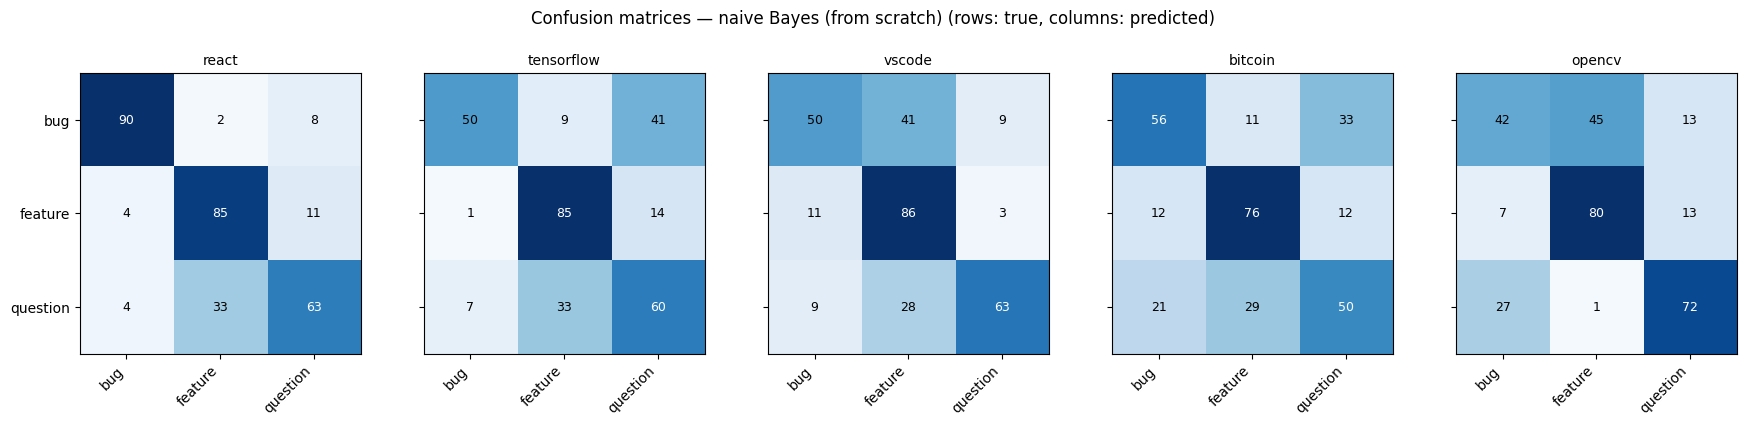

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8))
for ax, repo in zip(axes, REPOSITORIES):
    matrix = best.per_repository[repo].confusion_frame()
    im = ax.imshow(matrix.values, cmap="Blues", vmin=0, vmax=matrix.values.max())
    ax.set_xticks(range(len(LABELS)), LABELS, rotation=45, ha="right")
    ax.set_yticks(range(len(LABELS)), LABELS if repo == REPOSITORIES[0] else [""] * 3)
    ax.set_title(repo.split("/")[-1], fontsize=10)
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            value = matrix.values[i, j]
            ax.text(j, i, value, ha="center", va="center", fontsize=9,
                    color="white" if value > matrix.values.max() * 0.6 else "black")
fig.suptitle(f"Confusion matrices — {best.model_name} (rows: true, columns: predicted)", y=1.04)
fig.tight_layout()
fig.savefig(RESULTS / "figures" / "confusion_reference.png", dpi=200, bbox_inches="tight")

---
## 6. Does per-project training actually help?

The competition mandates one classifier per project, which means each is trained on only 300 issues instead of 1,500. That is a real cost, so it is worth checking whether the specialisation pays for the lost data. Track A's EDA suggested it would: cross-project vocabulary overlap was low.

In [12]:
from statistics import mean

# One global classifier trained on all 1,500 issues, still scored per project.
X_train, y_train = train.texts_and_labels()
global_model = MultinomialNaiveBayes().fit(X_train, y_train)

per_project = next(r for r in competition_results if "naive Bayes" in r.model_name)
rows = []
for repo in REPOSITORIES:
    subset = test.by_repo(repo)
    global_f1 = evaluate(
        [i.label for i in subset],
        global_model.predict([i.text for i in subset]),
        labels=LABELS,
    ).macro_f1
    rows.append({
        "repository": repo,
        "per-project (300 train)": per_project.repository_f1[repo],
        "global (1500 train)": global_f1,
        "difference": global_f1 - per_project.repository_f1[repo],
    })

frame = pd.DataFrame(rows).set_index("repository")
frame.loc["MEAN"] = frame.mean()
display(frame.round(4))

,per-project (300 train),global (1500 train),difference
repository,,,
facebook/react,0.7914,0.5955,-0.1959
tensorflow/tensorflow,0.6466,0.6137,-0.0329
microsoft/vscode,0.6609,0.6022,-0.0587
bitcoin/bitcoin,0.6030,0.5677,-0.0353
opencv/opencv,0.6375,0.6223,-0.0152
MEAN,0.6679,0.6003,-0.0676


**Per-project training wins on every repository**, by 0.068 on average, despite using a fifth of the training data. The gap is largest on `facebook/react` (0.20).

This is worth a paragraph in the report: it is direct evidence that issue-type vocabulary is project-specific, it independently confirms the low cross-project vocabulary overlap measured in Track A, and it means the competition's protocol is not an arbitrary constraint but the right modelling choice.

---
## 7. Persist the results

Results are written to JSON and LaTeX so the report can be rebuilt without re-training, and so the numbers in the report cannot drift from the numbers the code produced.

In [13]:
for result in competition_results:
    slug = result.model_name.replace(" ", "_").replace("(", "").replace(")", "")
    save_result(result, RESULTS / "tables" / f"competition_{slug}.json")

for name, result in cv_results.items():
    slug = name.replace(" ", "_").replace("(", "").replace(")", "")
    save_result(result, RESULTS / "tables" / f"cv_{slug}.json")

print(sorted(p.name for p in (RESULTS / "tables").glob("*.json")))

['competition_keyword_rules.json', 'competition_majority.json', 'competition_naive_Bayes_from_scratch.json', 'competition_random_stratified.json', 'cv_keyword_rules.json', 'cv_majority.json', 'cv_naive_Bayes_from_scratch.json', 'cv_random_stratified.json']


In [14]:
latex = to_latex(
    board,
    caption=(
        "Per-repository and cross-repository $F_1$ of the reference models "
        "against the NLBSE'24 SetFit baseline."
    ),
    label="reference-leaderboard",
    path=RESULTS / "tables" / "leaderboard.tex",
)
print(latex)

\begin{table}[htbp]
  \centering
  \caption{Per-repository and cross-repository $F_1$ of the reference models against the NLBSE'24 SetFit baseline.}
  \label{tab:reference-leaderboard}
\begin{tabular}{lrrrrrrr}
\toprule
 & facebook/react & tensorflow/tensorflow & microsoft/vscode & bitcoin/bitcoin & opencv/opencv & overall & vs SetFit \\
model &  &  &  &  &  &  &  \\
\midrule
SetFit (NLBSE'24 baseline) & 0.8718 & 0.8644 & 0.8262 & 0.7555 & 0.8173 & 0.8270 & 0.0000 \\
naive Bayes (from scratch) & 0.7914 & 0.6466 & 0.6609 & 0.6030 & 0.6375 & 0.6679 & -0.1591 \\
keyword rules & 0.5712 & 0.6239 & 0.4582 & 0.4945 & 0.5498 & 0.5395 & -0.2875 \\
random (stratified) & 0.3428 & 0.3194 & 0.3428 & 0.3365 & 0.3326 & 0.3348 & -0.4922 \\
majority & 0.1667 & 0.1667 & 0.1667 & 0.1667 & 0.1667 & 0.1667 & -0.6603 \\
\bottomrule
\end{tabular}
\end{table}



---
## 8. How tracks B and C plug in

Any object with `fit(X, y)` and `predict(X)` works. For scikit-learn, that is a `Pipeline` directly:

```python
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

def svm_factory():
    return make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2), LinearSVC())

# model selection
result = cross_validate(svm_factory, train, k=10, model_name="TF-IDF + LinearSVC")

# final number, once
final = evaluate_competition(svm_factory, train, test, model_name="TF-IDF + LinearSVC")
```

Note it is a **factory**, not a model: each fold and each project needs a fresh untrained instance.

For a transformer, wrap fine-tuning in the same two methods and it drops into exactly these calls.

### Rules for everyone

1. **Select on cross-validation, report on the test split.** Call `evaluate_competition` once, when the model is final.
2. **Keep the seed.** `RANDOM_SEED = 42` everywhere, so folds are identical across machines and members.
3. **Save every result.** `save_result(...)` into `results/tables/`, so the report rebuilds without re-training.
4. **Report the spread, not just the mean.** `std_macro_f1` goes in the table.

---
## 9. Summary

| Model | CV macro F1 | Test F1 (competition) | vs SetFit |
|---|---|---|---|
| Majority class | 0.1667 | 0.1667 | −0.660 |
| Random (stratified) | 0.3626 | 0.3348 | −0.492 |
| Keyword rules | 0.5107 | 0.5395 | −0.288 |
| Naive Bayes (from scratch) | 0.6009 | 0.6679 | −0.159 |
| **SetFit (NLBSE'24 baseline)** | — | **0.8270** | — |

The floors are set. A from-scratch naive Bayes on cleaned text reaches 0.668, which leaves **0.159 for tracks B and C to close**. Anything below 0.54 is not beating hand-written keyword rules and should be treated as a bug rather than a result.